# WillmorePINN Demo: Learning Surfaces that Minimize Willmore Energy

This notebook demonstrates how a physics-informed neural network (PINN) learns a 3D surface
embedding $\varphi:(u,v) \to (x,y,z)$ that minimizes the **Willmore energy functional**:

$$W = \int H^2 \, dA$$

where $H$ is the mean curvature and $dA = \sqrt{EG - F^2}\,du\,dv$ is the surface area element.

**Known minimizers:**

| Genus | Surface | $W_{\min}$ | Value |
|-------|---------|-----------|-------|
| 0 | Round sphere | $4\pi$ | $\approx 12.566$ |
| 1 | Clifford torus | $2\pi^2$ | $\approx 19.739$ |
| 2 | Lawson $\xi_{2,1}$ (conjectured) | $4\pi^2$ | $\approx 39.478$ |

We focus on **genus 1 (torus)** as the primary demo target.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from model import EmbeddingNetwork, create_embedding_model
from losses import EmbeddingWillmoreLoss, RegularityLoss, CombinedEmbeddingLoss, create_embedding_loss
from sampling import (
    sample_parameters, sample_sphere_parameters,
    get_flat_torus_embedding, get_ellipsoid_embedding,
    get_theoretical_minimum_willmore, transform_square_to_parallelogram,
)
from utils import plot_surface_3d, plot_fundamental_domain_coloring, compute_mean_curvature_at_points
from run import train_epoch

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cpu")
dtype = torch.float32

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.11.0
Device: cpu


## 1. Reference Surfaces (Analytical Embeddings)

Before training any neural network, let us visualize the **analytical reference surfaces**
that serve as starting points and comparison targets.

The sampling module provides parametric embeddings:
- `get_ellipsoid_embedding(uv, a, b, c)` maps $(u,v) \in [0,2\pi]\times[0,\pi]$ to an ellipsoid
- `get_flat_torus_embedding(uv, tau)` maps $(u,v)$ to a torus in $\mathbb{R}^3$ with complex modulus $\tau$

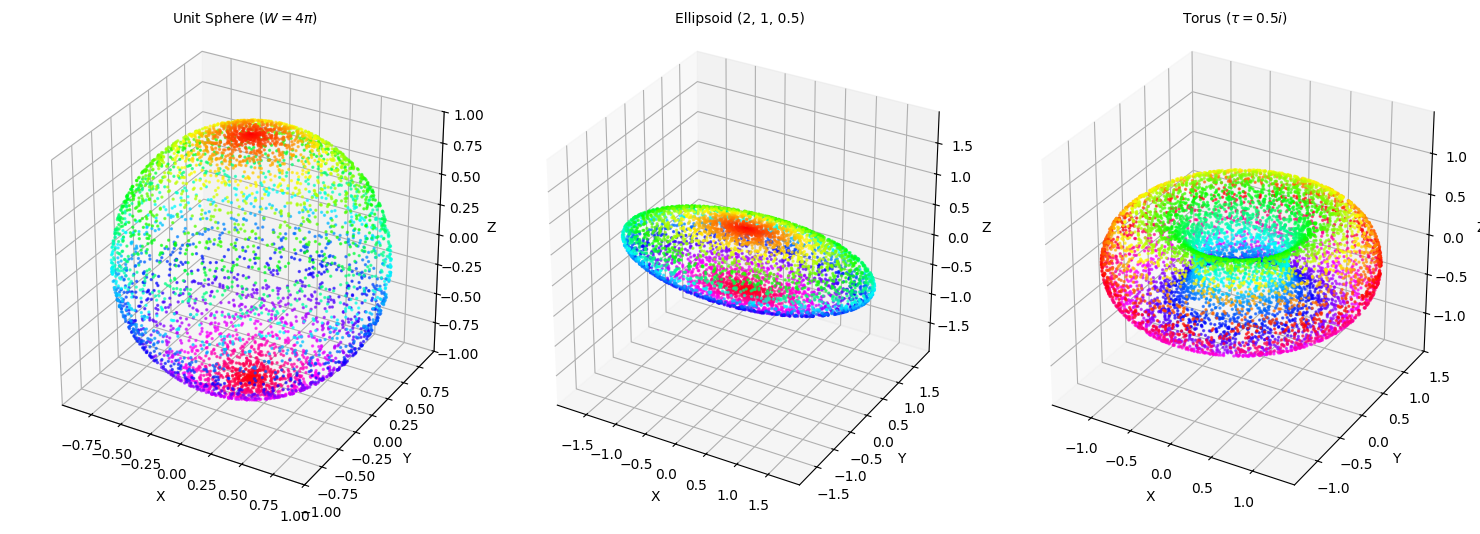

Theoretical minimum Willmore energy:
  Genus 0 (sphere): 12.5664
  Genus 1 (Clifford torus): 19.7392


In [2]:
# --- Genus 0: Sphere and Ellipsoid ---
uv_sphere = sample_sphere_parameters(5000, device=device, dtype=dtype)
xyz_sphere = get_ellipsoid_embedding(uv_sphere, a=1.0, b=1.0, c=1.0)
xyz_ellipsoid = get_ellipsoid_embedding(uv_sphere, a=2.0, b=1.0, c=0.5)

# --- Genus 1: Torus with tau = 0.5j ---
uv_torus = sample_parameters(8000, domain="torus", device=device, dtype=dtype)
tau = 0.5j
uv_transformed = transform_square_to_parallelogram(uv_torus, tau=tau)
xyz_torus = get_flat_torus_embedding(uv_transformed, tau=tau)

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
plot_surface_3d(ax1, xyz_sphere, uv_sphere, r"Unit Sphere ($W = 4\pi$)", genus=0)

ax2 = fig.add_subplot(132, projection='3d')
plot_surface_3d(ax2, xyz_ellipsoid, uv_sphere, "Ellipsoid (2, 1, 0.5)", genus=0)

ax3 = fig.add_subplot(133, projection='3d')
plot_surface_3d(ax3, xyz_torus, uv_torus, r"Torus ($\tau = 0.5i$)", genus=1)

plt.tight_layout()
plt.show()

print(f"Theoretical minimum Willmore energy:")
print(f"  Genus 0 (sphere): {get_theoretical_minimum_willmore(0):.4f}")
print(f"  Genus 1 (Clifford torus): {get_theoretical_minimum_willmore(1):.4f}")

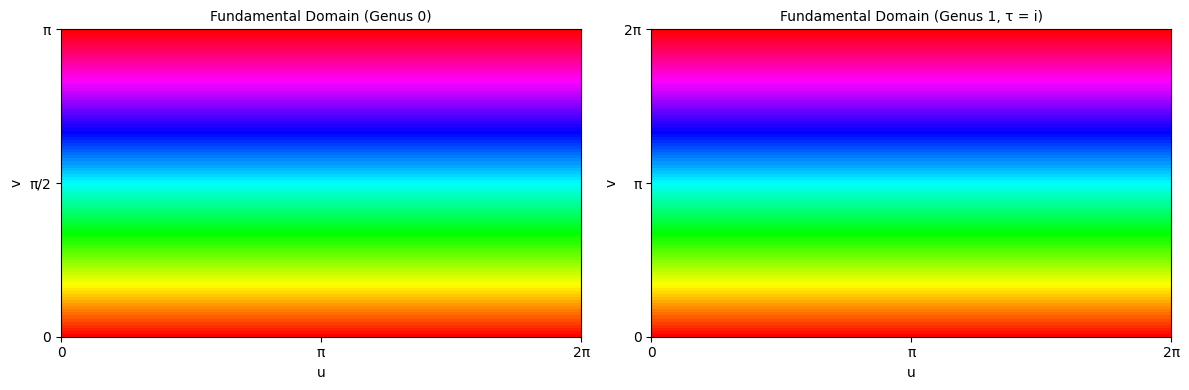

In [3]:
# Fundamental domain coloring shows how parameter space maps to the surface
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_fundamental_domain_coloring(axes[0], genus=0, num_points=100)
plot_fundamental_domain_coloring(axes[1], genus=1, num_points=100)

plt.tight_layout()
plt.show()

## 2. Model Architecture

The `EmbeddingNetwork` maps parameter coordinates $(u,v)$ to $\mathbb{R}^3$ via:

1. **Fourier feature layer** (`PeriodicEmbedding`): enforces periodicity by mapping
   $(u,v) \to (\sin(ku), \cos(ku), \sin(kv), \cos(kv))_{k=1}^{N_f}$, producing $4 N_f$ features.
2. **MLP backbone**: fully connected layers with tanh activations.
3. **Output layer**: linear map to $(x,y,z)$.

For genus 0, `SphericalHarmonicEmbedding` replaces Fourier features with real $Y_l^m(\theta,\phi)$.

In [4]:
# Instantiate a genus-1 model (skip_init=True to avoid pretraining for now)
model = EmbeddingNetwork(
    input_dim=2,
    output_dim=3,
    hidden_dims=[64, 128, 128, 64],
    activation="tanh",
    use_spectral_features=True,
    num_frequencies=2,
    initialization="xavier_uniform",
    use_residual=False,
    skip_init=True,
    genus=1,
    topology_params={"torus": {"tau": "0.5j"}},
)
model = model.to(device)

print(f"Trainable parameters: {model.count_parameters():,}")
print(f"Domain: {model.domain}")
print(f"Spectral features: {model.use_spectral_features}")
print(f"\nModel structure:")
print(model)

Trainable parameters: 33,859
Domain: torus
Spectral features: True

Model structure:
EmbeddingNetwork(
  (periodic_layer): PeriodicEmbedding()
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [5]:
# Forward pass: (u, v) -> (x, y, z)
uv_demo = sample_parameters(5, domain="torus", device=device, dtype=dtype)

with torch.no_grad():
    xyz_demo = model(uv_demo)

print("Input (u, v):")
print(uv_demo)
print(f"\nOutput (x, y, z):")
print(xyz_demo)
print(f"\nInput shape:  {uv_demo.shape}")
print(f"Output shape: {xyz_demo.shape}")
print("\n(Random outputs since the model is untrained)")

Input (u, v):
tensor([[2.1332, 2.2116],
        [1.7572, 5.3908],
        [2.8615, 5.0407],
        [2.8986, 4.8307],
        [5.6028, 0.5547]])

Output (x, y, z):
tensor([[ 0.2757,  0.9345,  0.1706],
        [ 0.2062,  0.5731, -0.0205],
        [ 0.6473,  0.5865,  0.0466],
        [ 0.6613,  0.5347,  0.1370],
        [-0.4836, -0.8466, -0.1538]])

Input shape:  torch.Size([5, 2])
Output shape: torch.Size([5, 3])

(Random outputs since the model is untrained)


## 3. Differential Geometry via Automatic Differentiation

The Willmore energy requires computing the **first** and **second fundamental forms**
of the embedding $\varphi(u,v)$:

**First fundamental form** (metric tensor):
$$I = \begin{pmatrix} E & F \\ F & G \end{pmatrix}, \quad
E = \langle\varphi_u, \varphi_u\rangle, \quad
F = \langle\varphi_u, \varphi_v\rangle, \quad
G = \langle\varphi_v, \varphi_v\rangle$$

**Second fundamental form**:
$$\text{II} = \begin{pmatrix} L & M \\ M & N \end{pmatrix}, \quad
L = \langle\varphi_{uu}, \mathbf{n}\rangle, \quad
M = \langle\varphi_{uv}, \mathbf{n}\rangle, \quad
N = \langle\varphi_{vv}, \mathbf{n}\rangle$$

where $\mathbf{n} = \frac{\varphi_u \times \varphi_v}{|\varphi_u \times \varphi_v|}$.

**Mean curvature**: $H = \frac{EN - 2FM + GL}{2(EG - F^2)}$

All derivatives are computed exactly via PyTorch's `torch.func.vmap` and `jacfwd` (forward-mode AD).

In [6]:
# To compute meaningful curvature, we first need a model that approximates a known surface.
# create_embedding_model() runs supervised pretraining automatically.

geom_config = {
    "topology": {"genus": 1, "torus": {"tau": "0.5j"}},
    "model": {
        "input_dim": 2, "output_dim": 3,
        "hidden_dims": [64, 128, 128, 64],
        "activation": "tanh", "dropout": 0.0,
        "use_spectral_features": True, "num_frequencies": 2,
        "initialization": "xavier_uniform",
        "use_residual": False, "residual_scale": 0.5,
        "freq_curriculum": {"warmup_epochs": 0, "start_freqs": 1},
        "supervised_pretraining": {
            "enabled": True, "num_epochs": 30,
            "learning_rate": 0.003, "batch_size": 512,
            "num_points_per_epoch": 4096,
            "position_weight": 1.0, "derivative_weight": 1.0,
        },
    },
    "sampling": {"num_points": 4000},
    "output": {"checkpoint_dir": "checkpoints", "log_dir": "logs"},
}

print("Creating model with supervised pretraining (fits the reference torus)...")
model_geom = create_embedding_model(geom_config, device)

Creating model with supervised pretraining (fits the reference torus)...
  Supervised pretraining epoch [1/30]: Position loss = 0.189134, Derivative loss = 0.298357
  Supervised pretraining epoch [20/30]: Position loss = 0.000021, Derivative loss = 0.000398
Supervised pretraining complete after 30 epochs
Embedding model created for genus 1 (torus)
  Domain: torus
  Parameters: 33859 trainable


In [7]:
# Compute fundamental forms on 500 sample points
uv_sample = sample_parameters(500, domain="torus", device=device, dtype=dtype)
uv_sample.requires_grad_(True)

# First fundamental form
E, F, G, phi_u, phi_v = model_geom.compute_first_fundamental_form(uv_sample)

# Second fundamental form
L, M, N, normal = model_geom.compute_second_fundamental_form(uv_sample, phi_u, phi_v)

# Mean curvature
H = model_geom.compute_mean_curvature(E, F, G, L, M, N, epsilon=1e-6)

# Area element
area_element = torch.sqrt(torch.clamp(E * G - F * F, min=1e-8))

print("First fundamental form (first 5 points):")
print(f"  E (|phi_u|^2): {E[:5].detach().numpy()}")
print(f"  F (phi_u . phi_v): {F[:5].detach().numpy()}")
print(f"  G (|phi_v|^2): {G[:5].detach().numpy()}")
print(f"\nSecond fundamental form (first 5 points):")
print(f"  L: {L[:5].detach().numpy()}")
print(f"  M: {M[:5].detach().numpy()}")
print(f"  N: {N[:5].detach().numpy()}")
print(f"\nMean curvature H (first 5 points): {H[:5].detach().numpy()}")
print(f"Area element (first 5 points): {area_element[:5].detach().numpy()}")
print(f"\nmean |F| = {F.abs().mean().item():.6f} (should be small for near-conformal map)")
print(f"mean H^2 = {(H**2).mean().item():.4f}")

First fundamental form (first 5 points):
  E (|phi_u|^2): [0.5972182  0.2618403  1.5737954  0.3934124  0.75017375]
  F (phi_u . phi_v): [-0.00162108 -0.0034274  -0.00887708 -0.00636417 -0.00830195]
  G (|phi_v|^2): [0.23198822 0.2402201  0.24362794 0.2486527  0.25645328]

Second fundamental form (first 5 points):
  L: [ 0.39828756  0.46029803 -0.7034634   0.45640373  0.19138588]
  M: [ 4.6396903e-03 -3.4197411e-03  9.5241703e-05  1.7982617e-02
 -2.7967796e-02]
  N: [-0.52338076 -0.5038051  -0.56507504 -0.50323075 -0.5149852 ]

Mean curvature H (first 5 points): [-0.7945415  -0.1698832  -1.3834839  -0.43086585 -0.8780131 ]
Area element (first 5 points): [0.37221628 0.2507739  0.619146   0.31270203 0.438538  ]

mean |F| = 0.010544 (should be small for near-conformal map)
mean H^2 = 0.9311


## 4. Loss Functions

The training objective combines two terms:

1. **Willmore energy** $W = \int H^2\sqrt{EG - F^2}\,du\,dv$
   estimated via Monte Carlo: $W \approx \text{domain\_area} \times \frac{1}{N}\sum_i H_i^2 \sqrt{(EG-F^2)_i}$

2. **Regularity loss** prevents the parametrization from degenerating:
   - Area element floor: penalizes $\sqrt{EG-F^2} < \varepsilon_{\min}$
   - Metric positivity: ensures $E > 0$ and $G > 0$
   - Smoothness: penalizes $E$ or $G$ exceeding a maximum threshold

The combined loss is: $\mathcal{L} = w_W \cdot W + w_R \cdot R$

In [8]:
# Compute Willmore energy of the pretrained (~ reference) model
willmore_loss_fn = EmbeddingWillmoreLoss(epsilon=1e-6, domain="torus", genus=1)

uv_eval = sample_parameters(5000, domain="torus", device=device, dtype=dtype)
willmore_train, willmore_value = willmore_loss_fn(model_geom, uv_eval)

theoretical_min = get_theoretical_minimum_willmore(1)

print(f"Estimated Willmore energy (Monte Carlo, N=5000): {willmore_value:.4f}")
print(f"Theoretical minimum (Clifford torus):            {theoretical_min:.4f}")
print(f"Ratio W/W_min:                                   {willmore_value/theoretical_min:.4f}")
print(f"\nNote: tau=0.5j torus is NOT the Clifford torus, so W > 2*pi^2 is expected.")

Estimated Willmore energy (Monte Carlo, N=5000): 22.7226
Theoretical minimum (Clifford torus):            19.7392
Ratio W/W_min:                                   1.1511

Note: tau=0.5j torus is NOT the Clifford torus, so W > 2*pi^2 is expected.


In [9]:
# Regularity loss checks metric conditioning
regularity_loss_fn = RegularityLoss(
    epsilon=1e-6,
    min_area_element=0.01,
    area_element_weight=1.0,
    metric_positivity_weight=0.5,
    min_positivity=0.001,
    smoothness_weight=0.5,
    max_metric_value=5.0,
)

uv_reg = sample_parameters(2000, domain="torus", device=device, dtype=dtype)
reg_value = regularity_loss_fn(model_geom, uv_reg)

print(f"Regularity loss: {reg_value.item():.6f}")
print("(Should be very small for a well-conditioned reference surface)")

Regularity loss: 0.000000
(Should be very small for a well-conditioned reference surface)


In [10]:
# CombinedEmbeddingLoss wraps both into a single forward pass
combined_loss_fn = CombinedEmbeddingLoss(
    willmore_weight=1.0,
    regularity_weight=5.0,
    epsilon=1e-6,
    genus=1,
    domain="torus",
    max_willmore_weight=1.0,
)

uv_combined = sample_parameters(2000, domain="torus", device=device, dtype=dtype)
loss_dict = combined_loss_fn(model_geom, uv_combined)

print(f"Loss components:")
print(f"  Total loss:      {loss_dict['total'].item():.6f}")
print(f"  Willmore energy: {loss_dict['willmore']:.4f}")
print(f"  Regularity:      {loss_dict['regularity']:.6f}")

Loss components:
  Total loss:      3.858597
  Willmore energy: 23.1516
  Regularity:      0.000000


## 5. Training Demo: Genus 1 Torus

We now train a model from scratch to minimize the Willmore energy for a genus-1 torus.

The training follows two phases:
1. **Supervised pretraining**: The network learns to approximate a reference torus embedding
   ($\tau = 0.5j$, which has $W > 2\pi^2$).
2. **Willmore minimization**: The network deforms the surface to reduce $W$ toward the
   Clifford torus minimum $W = 2\pi^2 \approx 19.74$.

We use a small config for CPU feasibility: **50 epochs, 4000 sampling points**.

In [11]:
# Full training config
demo_config = {
    "topology": {"genus": 1, "torus": {"tau": "0.5j"}},
    "model": {
        "input_dim": 2, "output_dim": 3,
        "hidden_dims": [64, 128, 128, 64],
        "activation": "tanh", "dropout": 0.0,
        "use_spectral_features": True, "num_frequencies": 2,
        "initialization": "xavier_uniform",
        "use_residual": False, "residual_scale": 0.5,
        "freq_curriculum": {"warmup_epochs": 0, "start_freqs": 1},
        "supervised_pretraining": {
            "enabled": True, "num_epochs": 20,
            "learning_rate": 0.003, "batch_size": 512,
            "num_points_per_epoch": 4096,
            "position_weight": 1.0, "derivative_weight": 1.0,
        },
    },
    "sampling": {"num_points": 4000},
    "loss": {
        "willmore_weight": 1.0, "max_willmore_weight": 1.0,
        "regularity_weight": 5.0, "epsilon": 1e-6,
        "regularity_min_area_element": 0.01,
        "regularity_area_element_weight": 1.0,
        "regularity_min_positivity": 0.001,
        "regularity_metric_positivity_weight": 0.5,
        "regularity_max_metric_value": 5.0,
        "regularity_smoothness_weight": 0.5,
    },
    "output": {"checkpoint_dir": "checkpoints", "log_dir": "logs"},
}

print("Creating model (supervised pretraining runs automatically)...")
demo_model = create_embedding_model(demo_config, device)
demo_loss_fn = create_embedding_loss(demo_config)

Creating model (supervised pretraining runs automatically)...
  Supervised pretraining epoch [1/20]: Position loss = 0.189195, Derivative loss = 0.352773
  Supervised pretraining epoch [20/20]: Position loss = 0.000020, Derivative loss = 0.000406
Supervised pretraining complete after 20 epochs
Embedding model created for genus 1 (torus)
  Domain: torus
  Parameters: 33859 trainable


In [12]:
# Training loop
optimizer = optim.Adam(demo_model.parameters(), lr=3e-4, weight_decay=1e-6)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-7)

history = {"epoch": [], "total_loss": [], "willmore_energy": [], "regularity": [], "gluing": [], "genus": 1}

num_epochs = 50
theoretical_min = get_theoretical_minimum_willmore(1)

print(f"Training for {num_epochs} epochs...")
print(f"Target: Clifford torus W = 2*pi^2 = {theoretical_min:.4f}")
print(f"{'Epoch':>5}  {'Total Loss':>11}  {'Willmore':>10}  {'Regularity':>11}  {'LR':>10}")
print("-" * 60)

for epoch in range(1, num_epochs + 1):
    epoch_losses = train_epoch(
        model=demo_model, loss_fn=demo_loss_fn, optimizer=optimizer,
        num_points=4000, batch_size=2000, domain="torus",
        device=device, dtype=dtype, gradient_clip=1.0, genus=1,
    )
    scheduler.step()

    history["epoch"].append(epoch)
    history["total_loss"].append(epoch_losses["total"])
    history["willmore_energy"].append(epoch_losses["willmore"])
    history["regularity"].append(epoch_losses["regularity"])
    history["gluing"].append(0.0)

    if epoch % 10 == 0 or epoch == 1:
        lr = scheduler.get_last_lr()[0]
        print(f"{epoch:5d}  {epoch_losses['total']:11.6f}  {epoch_losses['willmore']:10.4f}  "
              f"{epoch_losses['regularity']:11.6f}  {lr:10.2e}")

print("-" * 60)
print(f"Final Willmore energy: {history['willmore_energy'][-1]:.4f}")
print(f"Clifford minimum:     {theoretical_min:.4f}")
print(f"Ratio W/W_min:        {history['willmore_energy'][-1]/theoretical_min:.4f}")

Training for 50 epochs...
Target: Clifford torus W = 2*pi^2 = 19.7392
Epoch   Total Loss    Willmore   Regularity          LR
------------------------------------------------------------
    1     3.811556     22.8693     0.000000    3.00e-04
   10     3.373665     20.2420     0.000000    2.71e-04
   20     3.311249     19.8675     0.000000    1.96e-04
   30     3.281328     19.6880     0.000000    1.04e-04
   40     3.336194     20.0172     0.000000    2.87e-05
   50     3.278049     19.6683     0.000000    1.00e-07
------------------------------------------------------------
Final Willmore energy: 19.6683
Clifford minimum:     19.7392
Ratio W/W_min:        0.9964


## 6. Visualization

Let us visualize:
1. The **trained surface** compared to the initial reference surface
2. **Loss curves** over training
3. A **mean curvature heatmap** on the learned surface

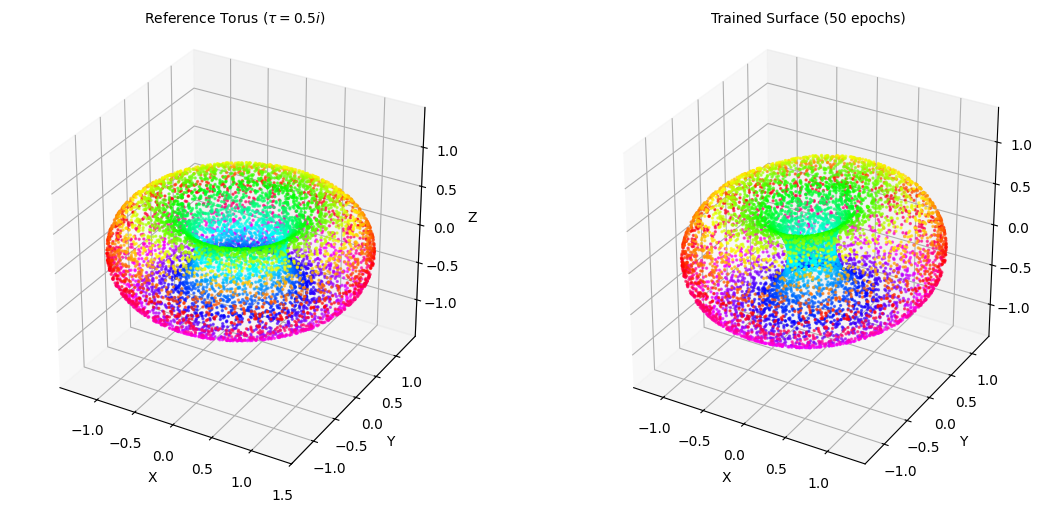

In [13]:
# Compare reference torus vs trained surface
uv_vis = sample_parameters(8000, domain="torus", device=device, dtype=dtype)

# Reference torus (tau = 0.5j)
uv_ref_transformed = transform_square_to_parallelogram(uv_vis, tau=0.5j)
xyz_ref = get_flat_torus_embedding(uv_ref_transformed, tau=0.5j)

# Trained model
with torch.no_grad():
    xyz_trained = demo_model(uv_vis)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
plot_surface_3d(ax1, xyz_ref, uv_vis, r"Reference Torus ($\tau = 0.5i$)", genus=1)

ax2 = fig.add_subplot(122, projection='3d')
plot_surface_3d(ax2, xyz_trained, uv_vis, f"Trained Surface ({num_epochs} epochs)", genus=1)

plt.tight_layout()
plt.show()

/var/folders/vx/ftrg36ns3qg15t94j080x7ww0000gn/T/ipykernel_72583/4136807977.py:28: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[2].set_yscale("log")


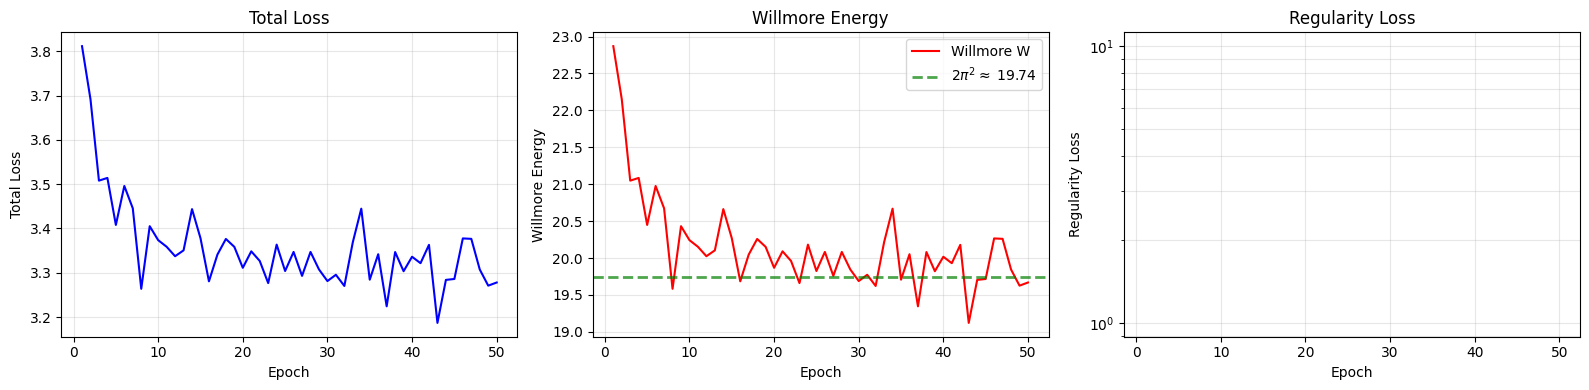

In [14]:
# Loss curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs = history["epoch"]

# Total loss
axes[0].plot(epochs, history["total_loss"], "b-", linewidth=1.5)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total Loss")
axes[0].set_title("Total Loss")
axes[0].grid(True, alpha=0.3)

# Willmore energy
axes[1].plot(epochs, history["willmore_energy"], "r-", linewidth=1.5, label="Willmore W")
axes[1].axhline(y=theoretical_min, color="g", linestyle="--", linewidth=2, alpha=0.7,
                label=f"$2\\pi^2 \\approx$ {theoretical_min:.2f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Willmore Energy")
axes[1].set_title("Willmore Energy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Regularity
axes[2].plot(epochs, history["regularity"], "g-", linewidth=1.5)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Regularity Loss")
axes[2].set_title("Regularity Loss")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

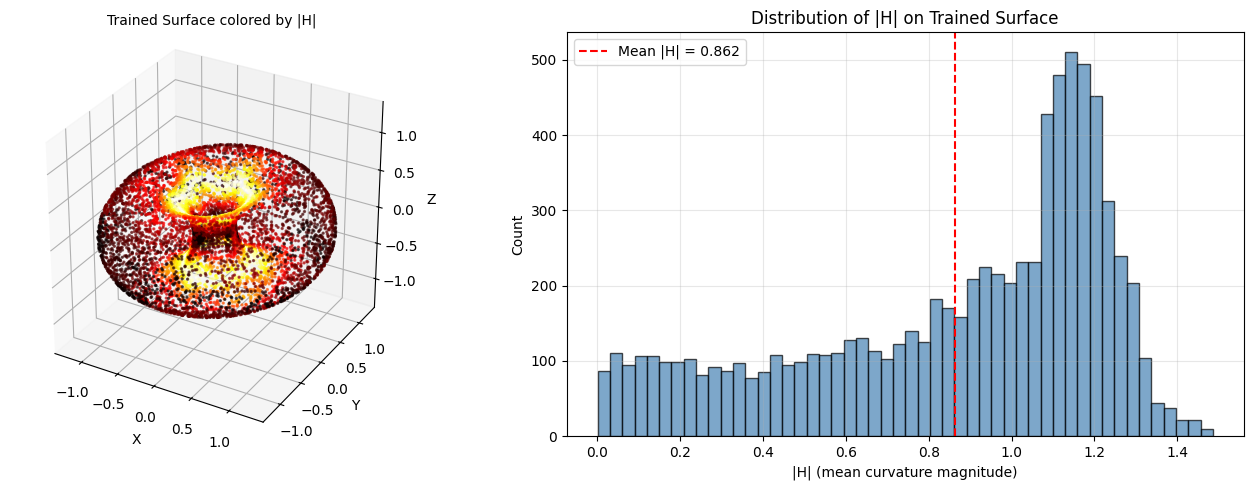

Mean |H|: 0.8623
Max  |H|: 1.4860
Std  |H|: 0.3702

For the Clifford torus, |H| = 1/sqrt(2) = 0.7071 everywhere.


In [15]:
# Mean curvature heatmap on the trained surface
uv_curv = sample_parameters(8000, domain="torus", device=device, dtype=dtype)
H_abs = compute_mean_curvature_at_points(demo_model, uv_curv, epsilon=1e-6)

with torch.no_grad():
    xyz_curv = demo_model(uv_curv)

fig = plt.figure(figsize=(14, 5))

# 3D surface colored by |H|
ax1 = fig.add_subplot(121, projection='3d')
plot_surface_3d(ax1, xyz_curv, uv_curv, "Trained Surface colored by |H|",
                genus=1, color_values=H_abs, cmap="hot_r",
                vmin=0, vmax=float(H_abs.quantile(0.95)))

# Histogram of |H|
ax2 = fig.add_subplot(122)
ax2.hist(H_abs.numpy(), bins=50, color="steelblue", edgecolor="black", alpha=0.7)
ax2.axvline(x=H_abs.mean().item(), color="red", linestyle="--",
            label=f"Mean |H| = {H_abs.mean().item():.3f}")
ax2.set_xlabel("|H| (mean curvature magnitude)")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of |H| on Trained Surface")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean |H|: {H_abs.mean().item():.4f}")
print(f"Max  |H|: {H_abs.max().item():.4f}")
print(f"Std  |H|: {H_abs.std().item():.4f}")
print(f"\nFor the Clifford torus, |H| = 1/sqrt(2) = {1/np.sqrt(2):.4f} everywhere.")

## Summary

This notebook demonstrated the core components of WillmorePINN:

1. **Analytical reference surfaces** --- parametric embeddings of ellipsoids and tori
2. **Neural network architecture** --- Fourier features enforce periodicity; the MLP maps to $\mathbb{R}^3$
3. **Differential geometry via autodiff** --- first/second fundamental forms, mean curvature $H$
4. **Willmore energy computation** --- Monte Carlo estimation of $\int\!\int H^2\,dA$
5. **Training loop** --- supervised pretraining + Willmore minimization drives $W \to 2\pi^2$
6. **Visualization** --- 3D surfaces, loss curves, curvature heatmaps

### Next steps

- **Longer training**: Run `python run.py --config configs/config_genus1.yaml` for 200+ epochs
  to see convergence toward the Clifford torus.
- **Genus 0**: Try `configs/config_genus0.yaml` --- an ellipsoid deforming into a round sphere.
- **Genus 2**: Try `configs/config_genus2.yaml` --- two tori glued along excised disks,
  targeting the Lawson surface $\xi_{2,1}$.